Deep Learning for text data (1)

In [1]:
from google.colab import files
from IPython.display import clear_output
files.upload()
clear_output()

Deep learning for natural-language processing is pattern recognition applied to words,
sentences, and paragraphs, in much the same way that computer vision is pattern
recognition applied to pixels.

In this unit we explore deep-learning models that can process text (understood as
sequences of word or sequences of characters), timeseries, and sequence data in general.

Two of fundamental deep-learning algorithms for sequence processing are recurrent
neural networks and 1D convnets, the one-dimensional version of the 2D convnets that
we covered previously. We’ll discuss both of these approaches in this
unit. Later, we will study recent architectures based on the concept of attention, such as transformers,
which are the basis of current models in natural language processing.


Applications of these algorithms include the following:

- Document classification and timeseries classification, such as identifying the topic of an
article or the author of a book
- Timeseries comparisons, such as estimating how closely related two documents or two
stock tickers are
- Sequence-to-sequence learning, such as decoding an English sentence into French
- Sentiment analysis, such as classifying the sentiment of tweets or movie reviews as
positive or negative
- Timeseries forecasting, such as predicting the future weather at a certain location, given recent weather data


The deep-learning sequence-processing models that we’ll introduce in the
following sections can use text to produce a basic form of natural language
understanding, sufficient for applications including document classification, sentiment
analysis, author identification, and even answering questions (in a constrained context).

Of course, keep in mind throughout this unit that none of these deep-learning models
truly understand text in a human sense; rather, these models can map the statistical
structure of written language, which is sufficient to solve many textual tasks.


## Text vectorization (Encoding)


Like all other neural networks, deep-learning models don’t take as input raw text:
they only work with numeric tensors. Vectorizing text is the process of transforming text
into numeric tensors. This can be done in multiple ways:

- Segment text into words, and transform each word into a vector.
- Segment text into characters, and transform each character into a vector.
- Extract N-grams of words or characters, and transform each N-gram into a vector.
N-grams are overlapping groups of multiple consecutive words or characters.


Collectively, the different units into which you can break down text (words,
characters, or N-grams) are called **tokens**, and breaking text into such tokens is called
**tokenization**.

All text-vectorization processes consist of applying some tokenization
scheme and then associating numeric vectors with the generated tokens. These vectors,
packed into sequence tensors, are fed into deep neural networks.


There are multiple ways to associate a vector with a token. The two major ones are: *one-hot encoding* of tokens, and *token embedding* (typically used exclusively for words, and
called *word embedding*).


# Word embeddings

Whereas the vectors obtained through one-hot encoding are binary, sparse (mostly made of zeros), and very high-dimensional (same dimensionality as the number of words in the vocabulary), word embeddings are
low-dimensional floating-point vectors (that is, dense vectors, as opposed to sparse
vectors). Unlike the word vectors obtained via one-hot encoding, word
embeddings are learned from data. It’s common to see word embeddings that are
256-dimensional, 512-dimensional, or 1,024-dimensional when dealing with very large
vocabularies. On the other hand, one-hot encoding words generally leads to vectors that
are 20,000-dimensional or greater (capturing a vocabulary of 20,000 token, in this case).
So, word embeddings pack more information into far fewer dimensions.

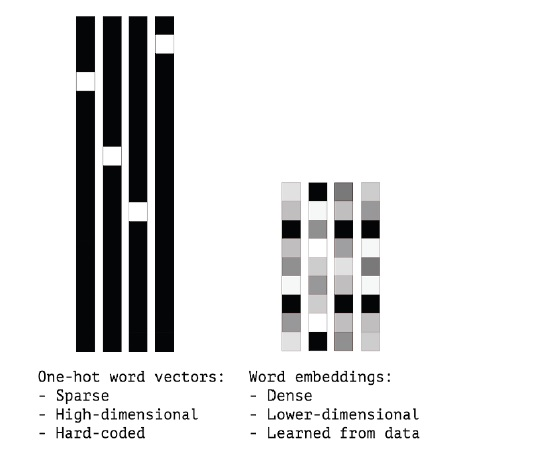

In [2]:
from IPython.display import Image, display
display(Image('embeddings.jpg'))

There are two ways to obtain word embeddings:

- Learn word embeddings jointly with the main task you care about (such as document
classification or sentiment prediction). In this setup, you start with random word vectors
and then learn word vectors in the same way you learn the weights of a neural network.
- Pretrained word embeddings. Load into your model word embeddings that were precomputed using a different
machine-learning task than the one you’re trying to solve.

## Learn word embeddings


The simplest way to associate a dense vector with a word is to choose the vector at
random. The problem with this approach is that the resulting embedding space has no
structure: for instance, the words `accurate` and `exact` may end up with completely
different embeddings, even though they’re interchangeable in most sentences. It’s
difficult for a deep neural network to make sense of such a noisy, unstructured
embedding space.

To get a bit more abstract, the geometric relationships between word vectors should
reflect the semantic relationships between these words. Word embeddings are meant to
map human language into a geometric space. For instance, in a reasonable embedding
space, you would expect synonyms to be embedded into similar word vectors; and in
general, you would expect the geometric distance (such as L2 distance) between any two
word vectors to relate to the semantic distance between the associated words (words
meaning different things are embedded at points far away from each other, whereas
related words are closer).


In real-world word-embedding spaces, common examples of meaningful geometric
transformations are "gender" vectors and "plural" vectors. For instance, by adding a
"female" vector to the vector "king", we obtain the vector "queen". By adding a "plural"
vector, we obtain "kings". Word-embedding spaces typically feature thousands of such
interpretable and potentially useful vectors.

Is there some ideal word-embedding space that would perfectly map human language
and could be used for any natural language-processing task? Possibly, but we have yet to
compute anything of the sort.


Also, there is no such a thing as human language—there
are many different languages, and they aren’t isomorphic, because a language is the
reflection of a specific culture and a specific context.

But more pragmatically, what
makes a good word-embedding space depends heavily on your task: the perfect
word-embedding space for an English-language movie-review sentiment-analysis model
may look different from the perfect embedding space for an English-language
legal-document-classification model, because the importance of certain semantic
relationships varies from task to task.



It’s thus reasonable to learn a new embedding space with every new task.
Fortunately, backpropagation makes this easy, and Keras makes it even easier. It’s about
learning the weights of a layer using `layer_embedding()`.

The embedding layer takes at least two arguments:

- the number of possible tokens, and
- the dimensionality of the embeddings.

A layer_embedding is best understood as a dictionary that maps integer indices
(which stand for specific words) to dense vectors. It takes integers as input, it looks up
these integers in an internal dictionary, and it returns the associated vectors. It’s
effectively a dictionary lookup.



An embedding layer takes as input a 2D tensor of integers, of shape:
`(samples,sequence_length)`, where each entry is a sequence of integers. It can embed sequences
of variable lengths: for instance, you could feed into the embedding layer in the previous
example batches with shapes (32, 10) (batch of 32 sequences of length 10) or (64,
15) (batch of 64 sequences of length 15). All sequences in a batch must have the same
length, though (because you need to pack them into a single tensor), so sequences that are
shorter than others should be padded with zeros, and sequences that are longer should be
truncated.

This layer returns a 3D floating-point tensor, of shape `(samples,
sequence_length, embedding_dimensionality)`. Such a 3D tensor can then be
processed by an RNN layer or a 1D convolution layer.


When you instantiate an embedding layer, its weights (its internal dictionary of token
vectors) are initially random, just as with any other layer. During training, these word
vectors are gradually adjusted via backpropagation, structuring the space into something
the downstream model can exploit. Once fully trained, the embedding space will show a
lot of structure —a kind of structure specialized for the specific problem for which you
were training your model.


### Example. Using an embedding layer and classifier on the IMDB data


IMDB Movie reviews sentiment classification

Description: Dataset of 25,000 movies reviews from IMDB, labeled by sentiment (positive/negative). Reviews have been **preprocessed**, and each review is encoded as a sequence of word indexes (integers). For convenience, words are indexed by overall frequency in the dataset, so that for instance the integer "3" encodes the 3rd most frequent word in the data.

In [3]:
max_features = 10000 # Max number of words to include
maxlen = 20 # sequences longer than this will be filtered out
from tensorflow.keras.datasets import imdb
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
print(type(x_train))
print(type(y_train))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [5]:
print(x_train[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]


In [6]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Padding de las secuencias
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

# Ver dimensiones (shape)
print(x_train.shape)

(25000, 20)


In [7]:
print(x_train[0,])

[  65   16   38 1334   88   12   16  283    5   16 4472  113  103   32
   15   16 5345   19  178   32]


The network will learn 8-dimensional embeddings for each of the 10,000 words, turn the input integer sequences (2D integer tensor) into embedded sequences (3D float tensor), flatten the tensor to 2D,
 and train a single dense layer on top for classification.


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense

# Crear modelo secuencial
model = Sequential([
    Embedding(input_dim=10000, output_dim=8, input_length=maxlen),
    Flatten(),
    Dense(1, activation='sigmoid')
])

# Resumen del modelo
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(x_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.6259 - loss: 0.6695 - val_acc: 0.6978 - val_loss: 0.6183
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.7491 - loss: 0.5439 - val_acc: 0.7320 - val_loss: 0.5260
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.7867 - loss: 0.4648 - val_acc: 0.7444 - val_loss: 0.5025
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.8100 - loss: 0.4250 - val_acc: 0.7542 - val_loss: 0.4923
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.8219 - loss: 0.3978 - val_acc: 0.7560 - val_loss: 0.4921
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.8371 - loss: 0.3747 - val_acc: 0.7588 - val_loss: 0.4942
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.8484 - loss: 0.3541 - val_acc: 0.7514 - val_loss: 0.5016
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.8590 - loss: 0.3347 - val_acc: 0.7536 - val_loss: 0.5042
Epoch 9/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - ac

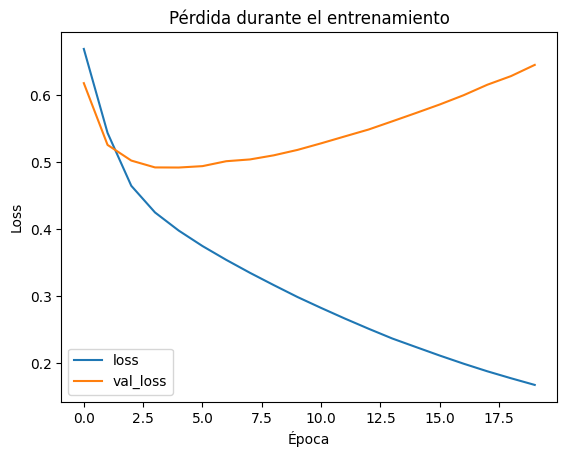

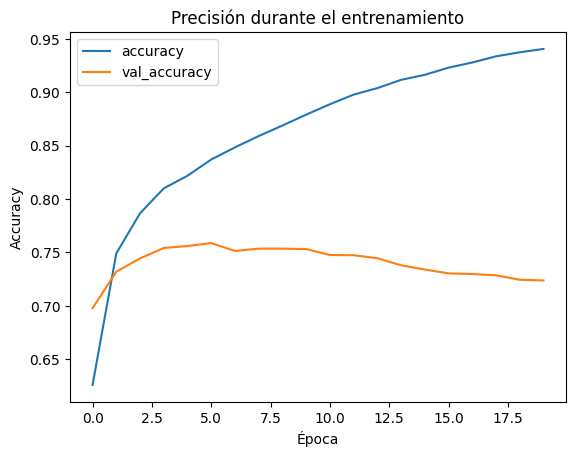

In [11]:
import matplotlib.pyplot as plt
# Pérdida
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(history.history['acc'], label='accuracy')
plt.plot(history.history['val_acc'], label='val_accuracy')
plt.title('Precisión durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

You get to a validation accuracy of ~76%, which is pretty good considering that
 you're only looking at 20 words from each review. But note that merely flattening
 the embedded sequences and training a single dense layer on top leads to a model that
 treats each word in the input sequence separately, without considering inter-word
 relationships and sentence structure (for example, this model would likely treat both "this
movie is a bomb" and "this movie is the bomb" as being negative reviews). It's much
 better to add recurrent layers or 1D convolutional layers on top of the embedded
 sequences to learn features that take into account each sequence as a whole. That's what
 we'll focus on in the next few sections.

 ## Pretrained word embeddings

Sometimes, you have so little training data available that you can’t use your data alone to
learn an appropriate task-specific embedding of your vocabulary. What do you do then?
Instead of learning word embeddings jointly with the problem you want to solve, you
can load embedding vectors from a precomputed embedding space that you know is
highly structured and exhibits useful properties—that captures generic aspects of
language structure. The rationale behind using pretrained word embeddings in natural
language processing is much the same as for using pretrained convnets in image
classification: you don’t have enough data available to learn truly powerful features on
your own, but you expect the features that you need to be fairly generic—that is,
common visual features or semantic features. In this case, it makes sense to reuse features
learned on a different problem.


Such word embeddings are generally computed using word-occurrence statistics
(observations about what words co-occur in sentences or documents), using a variety of
techniques, some involving neural networks, others not. The idea of a dense,
low-dimensional embedding space for words, computed in an unsupervised way, was
initially explored by Bengio et al. in the early 2000s, but it only started to take off in
research and industry applications after the release of one of the most famous and
successful word-embedding schemes: the Word2vec algorithm, developed by Tomas Mikolov at Google in 2013.


There are various precomputed databases of word embeddings that you can download
and use in a Keras embedding layer. Word2vec is one of them. Another popular one is
called Global Vectors for Word Representation (GloVe),
which was developed by Stanford researchers in 2014. This embedding technique is
based on factorizing a matrix of word co-occurrence statistics. Its developers have made
available precomputed embeddings for millions of English tokens, obtained from
Wikipedia data and Common Crawl data.

Let’s look at how you can get started using GloVe embeddings in a Keras model. The
same method will of course be valid for Word2vec embeddings or any other
word-embedding database. You’ll also use this example to refresh the text-tokenization
techniques we introduced a few paragraphs ago: you’ll start from raw text and work your
way up.

First, head to ai.stanford.edu/~amaas/data/sentiment and download the raw IMDB dataset
(if the URL isn’t working anymore, Google "IMDB dataset"). Uncompress it.
Now, let’s collect the individual training reviews into a list of strings, one string per
review. You’ll also collect the review labels (positive / negative) into a labels list.


### From raw text to word embeddings

In [ ]:
files.upload()
clear_output()


In [16]:
# per comprovar la ruta del contingut.
!ls /content

aclImdb		lstm1_2.JPG  lstm2.png	      rnn1.png	    sample_data
aclImdb.zip	lstm1_3.JPG  lstm.jpg	      rnn2.png
embeddings.jpg	lstm1_4.JPG  lstm_scheme.jpg  rnn3.png
gru.jpg		lstm1_5.JPG  lstm_scheme.png  rnn.png
lstm1_1.JPG	lstm1.png    lstm_v2.jpg      Rnntopos.png


In [17]:
!ls /content/aclImdb

aclImdb
aclImdb


In [18]:
!ls /content/aclImdb/aclImdb

aclImdb


In [19]:
import zipfile
import os

# Nombre del ZIP
zip_name = "aclImdb.zip"

# Carpeta donde se extraerá
extract_dir = "/content/aclImdb/aclImdb/aclImdb" # al pujar zip, esta aniada diverses cops, llavors s'afeigeix el nom de la caprteta 3 cops.

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Ahora extract_dir contiene carpetas "train" y "test"
texts = []
labels = []

train_dir = os.path.join(extract_dir, "train")

for label_type in ["neg", "pos"]:
    label = 0 if label_type == "neg" else 1
    dir_name = os.path.join(train_dir, label_type)

    for fname in os.listdir(dir_name):
        file_path = os.path.join(dir_name, fname)
        with open(file_path, "r", encoding="utf-8") as f:
            texts.append(f.read())
        labels.append(label)

print(f"Número de reseñas: {len(texts)}")
print(f"Número de etiquetas: {len(labels)}")

Número de reseñas: 25000
Número de etiquetas: 25000


In [21]:
print(texts[0])
print(labels[0])

With Knightly and O'Tool as the leads, this film had good possibilities, and with McCallum as the bad guy after Knightly, maybe some tension. But they threw it all away on silly evening frill and then later on with maudlin war remnants. It was of course totally superficial, beautiful English country and seaside or not.The number one mistake was dumping Knightly so early on in the film, when she could easily have played someone a couple of years older, instead of choosing someone ten years older to play the part. They missed all the chances to have great conflict among the cast, and instead stupidly pulled at the easy and low-cost heartstring elements.
0


In [22]:
# Tokenizing
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

max_words = 10000   # número máximo de palabras a considerar
maxlen = 50       # longitud máxima de cada reseña

# Crear el tokenizador y ajustarlo a los textos
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(texts)

# Convertir textos a secuencias de enteros
sequences = tokenizer.texts_to_sequences(texts)

# Diccionario de palabras (word index)
word_index = tokenizer.word_index
print(f"Found {len(word_index)} unique tokens.")

# Ejemplo de la primera secuencia
print(sequences[0])


Found 88582 unique tokens.
[16, 2, 14, 1, 829, 11, 19, 66, 49, 4348, 2, 16, 14, 1, 75, 229, 100, 276, 46, 1071, 18, 33, 3899, 9, 29, 242, 20, 705, 2186, 2, 92, 300, 20, 16, 322, 9, 13, 4, 261, 481, 3900, 304, 628, 701, 2, 39, 21, 1, 608, 28, 1318, 13, 35, 399, 20, 8, 1, 19, 51, 56, 97, 711, 25, 253, 291, 3, 375, 4, 150, 919, 302, 4, 5975, 291, 744, 150, 919, 5, 294, 1, 170, 33, 1045, 29, 1, 3417, 5, 25, 84, 1938, 790, 1, 174, 2, 302, 1898, 30, 1, 772, 2, 361, 2315, 788]


In [23]:
# Convertir a matriz 2D de tamaño (número_de_reviews, maxlen)
data = pad_sequences(sequences, maxlen=maxlen)

print("Shape of data tensor:", data.shape)
print("First sequence (padded):", data[0])

labels = np.array(labels)
print("Shape of label tensor:", labels.shape)

Shape of data tensor: (25000, 50)
First sequence (padded): [ 399   20    8    1   19   51   56   97  711   25  253  291    3  375
    4  150  919  302    4 5975  291  744  150  919    5  294    1  170
   33 1045   29    1 3417    5   25   84 1938  790    1  174    2  302
 1898   30    1  772    2  361 2315  788]
Shape of label tensor: (25000,)


In [24]:
training_samples = 200      # pequeño subset de entrenamiento
validation_samples = 10000  # subset de validación

# Generar índices aleatorios
indices = np.arange(data.shape[0])
np.random.shuffle(indices)

# Seleccionar índices de entrenamiento y validación
training_indices = indices[:training_samples]
validation_indices = indices[training_samples:training_samples + validation_samples]

# Crear conjuntos
x_train = data[training_indices]
y_train = labels[training_indices]
x_val = data[validation_indices]
y_val = labels[validation_indices]

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_val shape:", x_val.shape)
print("y_val shape:", y_val.shape)

x_train shape: (200, 50)
y_train shape: (200,)
x_val shape: (10000, 50)
y_val shape: (10000,)


*Word embedding*

Go to nlp.stanford.edu/projects/glove, and download the precomputed embeddings from
2014 English Wikipedia. It’s a 822 MB zip file called glove.6B.zip, containing
100-dimensional embedding vectors for 400,000 words (or nonword tokens). Unzip it.



In [31]:
files.upload()
clear_output()

FileNotFoundError: [Errno 2] No such file or directory: '/content/glove6B.zip'

In [32]:
!ls /content

aclImdb		lstm1_1.JPG  lstm1.png	      lstm_v2.jpg  Rnntopos.png
aclImdb.zip	lstm1_2.JPG  lstm2.png	      rnn1.png	   sample_data
embeddings.jpg	lstm1_3.JPG  lstm.jpg	      rnn2.png
glove.6B.zip	lstm1_4.JPG  lstm_scheme.jpg  rnn3.png
gru.jpg		lstm1_5.JPG  lstm_scheme.png  rnn.png


In [34]:
#descomprimimos zip
zip_path = "/content/glove.6B.zip"
extract_path = "/content/glove"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [35]:
file_path = os.path.join(extract_path, "glove.6B.100d.txt")

embeddings_index = {}

with open(file_path, encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]  # la palabra
        coefs = np.asarray(values[1:], dtype="float32")  # vector de 100 dimensiones
        embeddings_index[word] = coefs

print("Found", len(embeddings_index), "word vectors.")

Found 400000 word vectors.


In [36]:
#Examples
print(embeddings_index["after"])
print(embeddings_index["is"])
print(embeddings_index["sky"])

[ 3.7711e-01 -3.4471e-01  1.3405e-01 -1.1710e-02 -1.9427e-01  4.1464e-01
  4.0608e-01  4.3063e-01 -5.7060e-02 -1.9921e-01  4.3267e-01 -1.6269e-02
  2.1710e-01 -2.6149e-03  3.9424e-01 -4.2803e-01 -1.7495e-02 -5.6658e-01
 -4.4558e-01 -1.8529e-01  2.6732e-01 -1.5712e-01  2.1657e-01  7.9714e-01
  6.9623e-01  2.0405e-01 -4.9907e-01 -4.5519e-01  3.8210e-01  2.0603e-01
 -2.1606e-01  1.0093e-01 -5.0148e-01 -1.1058e-01 -4.3455e-01 -2.6785e-01
 -2.0234e-01  3.8320e-03 -4.9108e-01 -1.7642e-01 -8.8971e-01 -2.7900e-01
  8.6387e-01 -1.7356e-02  3.1210e-01  4.1004e-01  2.3199e-01 -6.0812e-01
  4.4763e-01 -8.9579e-01 -3.8491e-02 -2.5772e-01  3.9468e-01  1.6186e+00
 -5.4882e-01 -3.0291e+00 -7.7845e-01 -3.2463e-01  1.7658e+00  9.7303e-01
 -3.9342e-01  5.4811e-01  1.3164e-02  3.7850e-01  2.4538e-01  3.1079e-02
  2.3628e-01  2.8901e-01  2.7047e-02  2.8985e-01 -7.4523e-01  1.1517e-02
 -3.9456e-01 -5.7706e-01 -6.3604e-01  3.1022e-01 -3.8317e-01 -7.7663e-02
 -1.3539e+00  1.8009e-02  8.5646e-01  3.8259e-02 -3

Next, you’ll build an embedding matrix that you can load into an embedding layer. It
must be a matrix of shape (max_words, embedding_dim), where each entry $i$ contains
the embedding_dim-dimensional vector for the word of index $i$ in the reference word
index (built during tokenization). Note that index 1 isn’t supposed to stand for any word
or token—it’s a placeholder.


In [37]:
embedding_dim = 100  # dimensión del embedding (GloVe 100d)

# matriz de embeddings inicializada con ceros
embedding_matrix = np.zeros((max_words, embedding_dim))

for word, index in word_index.items():
    if index < max_words:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[index] = embedding_vector

In [38]:
print(embedding_matrix.shape)

(10000, 100)


In [42]:
#Defining the model
model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_shape=(maxlen,)), # important indicar el input_shape
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 50, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │       160,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,160,065 (4.43 MB)

 Trainable params: 1,160,065 (4.43 MB)

 Non-trainable params: 0 (0.00 B)

Param of layer embedding are 1000000 equal to max_words=10000 times embedding_dim=100.


The embedding layer has a single weight matrix: a 2D float matrix where each entry i is
the word vector meant to be associated with index $i$. Simple enough. Load the GloVe
matrix you prepared into the embedding layer, the first layer in the model.

Additionally, you’ll freeze the weights of the embedding layer, following the same
rationale you’re already familiar with in the context of pretrained convnet features: when
parts of a model are pretrained (like your embedding layer) and parts are randomly
initialized (like your classifier), the pretrained parts shouldn’t be updated during training,
to avoid forgetting what they already know. The large gradient updates triggered by the
randomly initialized layers would be disruptive to the already-learned features.

In [43]:
model.layers[0].set_weights([embedding_matrix])
model.layers[0].trainable = False
model.summary()
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(x_train,y_train,epochs=20,batch_size=32,validation_data=(x_val,y_val))

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 50, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │       160,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,160,065 (4.43 MB)

 Trainable params: 160,065 (625.25 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 346ms/step - accuracy: 0.5350 - loss: 1.3940 - val_accuracy: 0.5277 - val_loss: 0.7067
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 250ms/step - accuracy: 0.7900 - loss: 0.4995 - val_accuracy: 0.4947 - val_loss: 1.1923
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - accuracy: 0.7200 - loss: 0.5122 - val_accuracy: 0.4948 - val_loss: 1.0839
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - accuracy: 0.8950 - loss: 0.3062 - val_accuracy: 0.4948 - val_loss: 1.2666
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - accuracy: 0.9350 - loss: 0.2403 - val_accuracy: 0.5197 - val_loss: 0.9455
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - accuracy: 0.9700 - loss: 0.1943 - val_accuracy: 0.5309 - val_loss: 0.8455
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.9850 - loss: 0.1354 - val_accuracy: 0.4950 - val_loss: 1.5322
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step - accuracy: 0.9450 - loss: 0.1267 - val_accuracy: 0.5578 - val_loss:

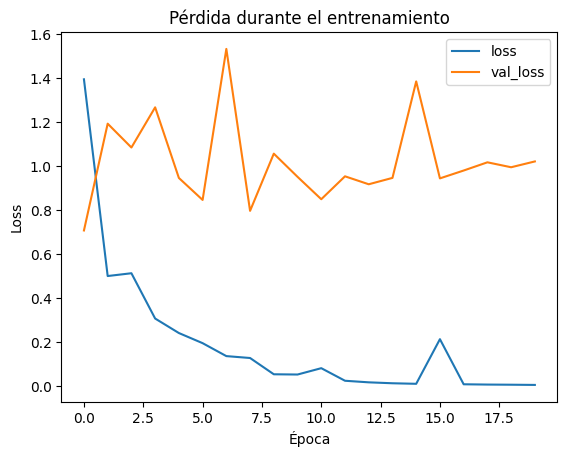

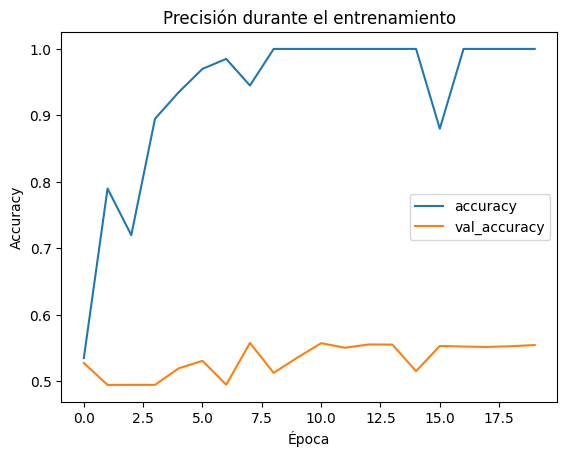

In [47]:
# Pérdida
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Precisión durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [50]:
# Guardar solo los pesos del modelo
model.save_weights("pre_trained_glove_model.weights.h5")

In [59]:
#Evaluating the model on the test set

test_dir = os.path.join(extract_dir, "test")

texts = []
labels = []

for label_type in ["neg", "pos"]:

    label = 0 if label_type == "neg" else 1
    dir_name = os.path.join(test_dir, label_type)

    for fname in os.listdir(dir_name):
        if fname.endswith(".txt"):

            with open(os.path.join(dir_name, fname), encoding="utf-8") as f:
                texts.append(f.read())

            labels.append(label)

In [60]:
#Convertir texto a secuencia
sequences = tokenizer.texts_to_sequences(texts)
x_test = pad_sequences(sequences, maxlen=maxlen)
y_test = np.array(labels)

In [62]:
# cargar pesos y evaluar
model.load_weights("pre_trained_glove_model.weights.h5")
model.evaluate(x_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5521 - loss: 1.0101


[1.0100624561309814, 0.5521199703216553]